# Driveline Baseball OpenBiomechanics Pitching Data Exploration
Data is from of [Driveline Baseball's OpenBiomechanics repository](https://github.com/drivelineresearch/openbiomechanics/tree/main).

## Data of Interest:
* **Pitching**:
  * Pitcher metadata
  * Standing leg force plate
  * Joint velocities to examine movement sequencing patterns

In [1]:
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport
from numpy.polynomial import polynomial
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Marchiano\AppData\Local\Temp\ipykernel_3788\3004358926.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install data-profiling via `pip install data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [2]:
# Import datasets
pitching_data_folder = 'C:\\Users\\Marchiano\\Documents\\Projects\Baseball-Biomechanics\\Pitching_biomechanics_data\\'

pitcher_metadata_df = pd.read_csv(pitching_data_folder + 'metadata.csv', header=0)
force_plate_df = pd.read_csv(pitching_data_folder + 'force_plate.csv', header=0)

## Pitcher Metadata

In [3]:
# Preview pitcher metadata
pitcher_metadata_df.head()

,user,session,session_pitch,session_mass_kg,session_height_m,age_yrs,playing_level,pitch_speed_mph,filename_new,modelname_new
0,750,1031,1031_2,110.6784,1.9304,21.40,college,90.4,000750_001031_76_244_013_FF_904.c3d,000750_001031_model.c3d
1,750,1031,1031_3,110.6784,1.9304,21.40,college,90.4,000750_001031_76_244_014_FF_904.c3d,000750_001031_model.c3d
2,774,1097,1097_1,101.1528,1.9304,19.41,college,77.6,000774_001097_76_223_001_FF_776.c3d,000774_001097_model.c3d
3,774,1097,1097_2,101.1528,1.9304,19.41,college,77.0,000774_001097_76_223_005_FF_770.c3d,000774_001097_model.c3d
4,774,1097,1097_3,101.1528,1.9304,19.41,college,76.1,000774_001097_76_223_006_FF_761.c3d,000774_001097_model.c3d


In [4]:
pitcher_profile = ProfileReport(pitcher_metadata_df[['session_mass_kg', 'session_height_m', 'age_yrs', 'playing_level', 'pitch_speed_mph']], 
                                title="Pitcher Metadata Profiling Report")
pitcher_profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 320.02it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### Simplied View of Metadata
Output playing level metadata breakdown for convenient view

In [5]:
pitcher_metadata_df['playing_level'].value_counts()

playing_level
college        314
independent     42
high_school     32
milb            23
Name: count, dtype: int64

In [6]:
pitcher_metadata_df.groupby('playing_level')[['session_mass_kg']].describe()

session_mass_kg                                           \
                        count        mean        std      min      25%   
playing_level                                                            
college                 314.0   88.450555   8.509943  69.4008  82.5552   
high_school              32.0   85.957200   9.044156  73.4832  76.2048   
independent              42.0  102.513600   8.540899  88.4520  98.4312   
milb                     23.0   99.101739  10.226249  83.4624  93.8952   

                                             
                    50%       75%       max  
playing_level                                
college         87.5448   93.8952  111.1320  
high_school     85.2768   96.1632   97.5240  
independent    103.4208  105.6888  118.3896  
milb            97.5240  103.8744  113.8536

In [7]:
pitcher_metadata_df.groupby('playing_level')[['session_height_m']].describe()

session_height_m                                              \
                         count      mean       std     min     25%     50%   
playing_level                                                                
college                  314.0  1.841500  0.069010  1.6764  1.8034  1.8542   
high_school               32.0  1.883569  0.042848  1.8288  1.8288  1.9050   
independent               42.0  1.885648  0.082030  1.6764  1.8796  1.8796   
milb                      23.0  1.879600  0.035095  1.8034  1.8542  1.8796   

                                
                   75%     max  
playing_level                   
college        1.87960  2.0320  
high_school    1.93040  1.9304  
independent    1.92405  2.0066  
milb           1.90500  1.9304

In [8]:
pitcher_metadata_df.groupby('playing_level')[['age_yrs']].describe()

age_yrs                                                         
                count       mean       std    min     25%    50%    75%    max
playing_level                                                                 
college         314.0  20.813280  1.502779  18.00  19.610  20.61  21.51  25.07
high_school      32.0  18.422812  0.426956  17.68  18.130  18.62  18.74  18.94
independent      42.0  24.977143  1.433975  22.26  24.055  25.04  25.61  27.59
milb             23.0  25.073478  1.543024  23.13  23.620  25.16  25.35  27.46

In [9]:
pitcher_metadata_df.groupby('playing_level')[['pitch_speed_mph']].describe()

pitch_speed_mph                                            \
                        count       mean       std   min     25%    50%   
playing_level                                                             
college                 314.0  84.733758  4.377185  71.4  81.825  85.10   
high_school              32.0  79.515625  3.848679  73.8  76.250  79.35   
independent              42.0  85.942857  5.429241  69.5  83.550  87.80   
milb                     23.0  89.247826  1.643685  86.3  87.850  89.40   

                            
                 75%   max  
playing_level               
college        87.70  94.4  
high_school    81.60  86.8  
independent    89.45  93.1  
milb           90.70  92.0

## 4-Seam Fastball Velocity (mph) vs. Standing Leg Force Applied (N)
Fastball velocity and force plate data is found in metadata.csv and force_plate.csv respectively.

**N.B.** 8 pitches in metadata.csv have corresponding biomechanical data (i.e., force plate data); hence the need to use pitch IDs to get correpsponding data from metadata.csv

In [10]:
# Function to denote where an event (e.g, pitch, swing) begins as indicated by time 0 in data
# ACCEPTS: pandas series with time data
# RETURNS: numpy array with indices from the pandas series denoting when each event begins

def get_event_starts(time_series_column):
    return np.where(time_series_column == 0)[0]

In [11]:
# Function to return an array with event ID and another arrray with the peak outcome measure value of interest for each recorded event (e.g., pitch, swing)
# ACCEPTS: - one dataframe consisting of the event ID column, time, at least 1 outcome measure column
#          - name of outcome measure column of interest as a string
# RETURNS: 2 numpy arrays: event IDs and outcome measure values (e.g., [1031_2, 1031_3,...], [1000, 1500,...])

def get_event_value(data_df, outcome_measure):

    # set constants
    event_id_column = data_df.columns[0] # assuming the dataset has the event ID in the first column like it is for driveline openbiomechanics datasets
    
    # crop events in dataframe
    event_starts_array = get_event_starts(data_df['time'])

    last_event_index = event_starts_array[-1] # to use to crop last event in dataset

    # preallocate lists to speed up computing
    n_events = len(event_starts_array) # determine number of events, which will be the size of list to preallocate
    event_array = np.empty(n_events, dtype=np.dtypes.StringDType()) # blank numpy array to add event ID strings (of variable lenght if needed) to and return upon completion
    value_array = np.empty(n_events) # blank numpy array to add values and return upon completion
    
    # use indices from event_starts_array to crop individual events
    for i, start_index in enumerate(event_starts_array):

        # last event case
        if start_index == last_event_index:
            event_array[i] = data_df[event_id_column].iloc[start_index]
            value_array[i] = data_df[outcome_measure].iloc[start_index:].max()
            
        # for all other events
        else:
            event_array[i] = data_df[event_id_column].iloc[start_index]
            value_array[i] = data_df[outcome_measure].iloc[start_index:event_starts_array[i+1]].max()
            
    return event_array, value_array

In [12]:
# Return an array for the pitch ID and an array for the peak rear (i.e., standing) leg ground reaction force Fz value for each recorded pitch
pitch_array, peak_fz_array = get_event_value(force_plate_df, 'rear_force_z')

In [13]:
# Using pitch IDs from pitch_array to get corresponding pitch_speed_mph and pitcher mass from metadata.csv
# Pitch velocity
pitch_velos_array = pitcher_metadata_df['pitch_speed_mph'][pitcher_metadata_df['session_pitch'].isin(pitch_array)].to_numpy()

# Pitcher mass
pitcher_mass_array = pitcher_metadata_df['session_mass_kg'][pitcher_metadata_df['session_pitch'].isin(pitch_array)].to_numpy()

# Calculate peak Fz normalized to pitcher mass
normalized_fz_array = peak_fz_array / pitcher_mass_array

## Plots

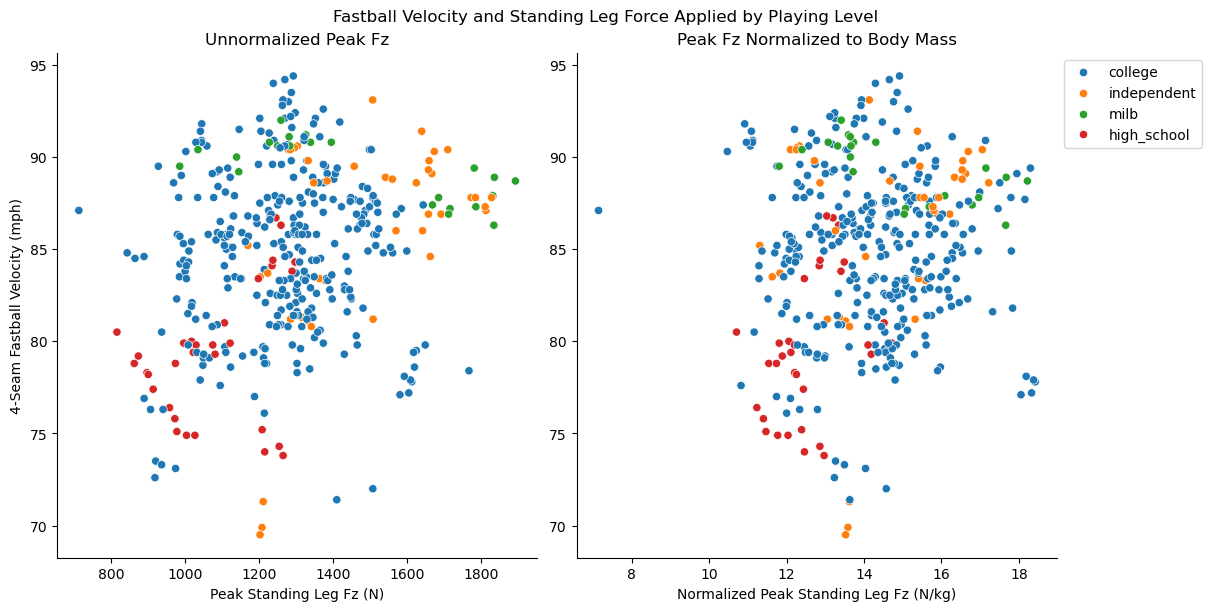

In [14]:
# Plot unnormalized and normalized 4-seam fastball velocity vs. force plate (Fz) values and distinguished by pitcher playing level

# Prepare data using pitch IDs from pitch_array to get corresponding playing level from metadata.csv
playing_level_array = pitcher_metadata_df['playing_level'][pitcher_metadata_df['session_pitch'].isin(pitch_array)].to_numpy()

# Set axes for plots
fig, (unnormalized_plot_axes, normalized_plot_axes) = plt.subplots(1, 2, figsize=(12,6), layout='constrained')
fig.suptitle('Fastball Velocity and Standing Leg Force Applied by Playing Level')

# Plot data (which is passed in as dataframe consisting of fastball velocity, Fz, playing level) using Seaborn where the line of best can be auto-generated
# Velocity vs. Unnormalized Peak Fz
sns.scatterplot(x=peak_fz_array, y=pitch_velos_array, hue=playing_level_array, legend=False, ax=unnormalized_plot_axes)
unnormalized_plot_axes.set_xlabel('Peak Standing Leg Fz (N)')
unnormalized_plot_axes.set_ylabel('4-Seam Fastball Velocity (mph)')
unnormalized_plot_axes.set_title('Unnormalized Peak Fz')
unnormalized_plot_axes.spines[['top', 'right']].set_visible(False)

# Velocity vs. Normalized Peak Fz
velo_normfz_plot = sns.scatterplot(x=normalized_fz_array, y=pitch_velos_array, hue=playing_level_array, legend='full', ax=normalized_plot_axes) # creating separate object to move the legend
sns.move_legend(velo_normfz_plot, loc='upper left', bbox_to_anchor=(1, 1))
normalized_plot_axes.set_xlabel('Normalized Peak Standing Leg Fz (N/kg)')
normalized_plot_axes.set_title('Peak Fz Normalized to Body Mass')
normalized_plot_axes.spines[['top', 'right']].set_visible(False)

In [15]:
# Mean Peak Standing Leg Fz and Fastball Velocity Data by Playing Level
fz_velocity_df = pd.DataFrame({'Unnormalized Fz': peak_fz_array,
                               'Normalized Fz': normalized_fz_array,
                               'Velocity': pitch_velos_array,
                               'Playing Level': playing_level_array})

fz_velocity_df.groupby('Playing Level')[['Unnormalized Fz', 'Normalized Fz', 'Velocity']].mean()

,Unnormalized Fz,Normalized Fz,Velocity
Playing Level,,,
college,1261.830059,14.250845,84.841694
high_school,1079.868631,12.552783,79.515625
independent,1485.119280,14.507928,85.897561
milb,1488.498048,14.899869,89.247826


In [16]:
# Scatter plots of 4-seam fastball velocity vs. force plate (Fz) values for linear regression

# Calculate line of best fit
# Unnormalized data
fit_coeff_unnormalized = polynomial.polyfit(peak_fz_array, pitch_velos_array, deg=1) # returns array in the form of [slope, intercept] for line of best fit
intercept_unnormalized = fit_coeff_unnormalized[0]
slope_unnormalized = fit_coeff_unnormalized[1]

# Normalized data
fit_coeff_normalized = polynomial.polyfit(normalized_fz_array, pitch_velos_array, deg=1) # returns array in the form of [slope, intercept] for line of best fit
intercept_normalized = fit_coeff_normalized[0]
slope_normalized = fit_coeff_normalized[1]

# Calculate Pearson R coefficient and R-squared values to further describe relationship
# Unnormalized data
pearson_r_unnormalized = np.corrcoef(peak_fz_array, pitch_velos_array)[0,1] # output is correlation matrix so must index to get Pearson R coefficient from matrix
r_squared_unnormalized = pearson_r_unnormalized**2

# Normalized data
pearson_r_normalized = np.corrcoef(normalized_fz_array, pitch_velos_array)[0,1] # output is correlation matrix so must index to get Pearson R coefficient from matrix
r_squared_normalized = pearson_r_normalized**2

Text(6.75, 81, 'R = 0.1061, R^2 = 0.0113')

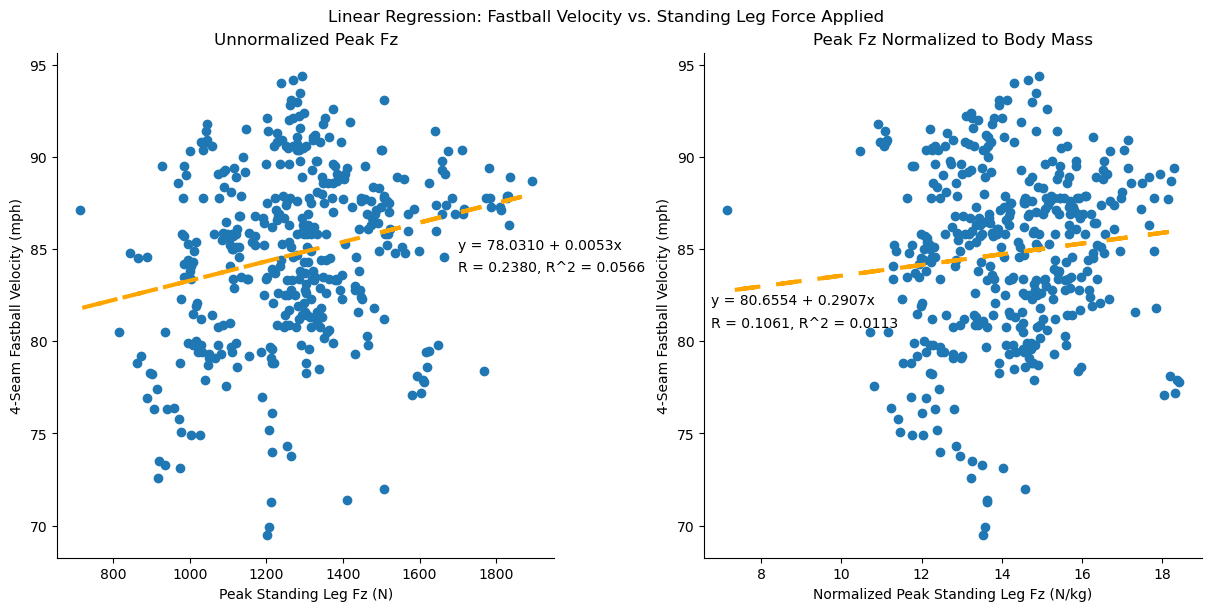

In [17]:
# Set axes for plots
fig, (unnormalized_regression_axes, normalized_regression_axes) = plt.subplots(1, 2, figsize=(12,6), layout='constrained')
fig.suptitle('Linear Regression: Fastball Velocity vs. Standing Leg Force Applied')

# Unnormalized
# Plot data
unnormalized_regression_axes.scatter(peak_fz_array, pitch_velos_array)
unnormalized_regression_axes.set_xlabel('Peak Standing Leg Fz (N)')
unnormalized_regression_axes.set_ylabel('4-Seam Fastball Velocity (mph)')
unnormalized_regression_axes.set_title('Unnormalized Peak Fz')
unnormalized_regression_axes.spines[['top', 'right']].set_visible(False)

# Plot line of best fit
unnormalized_regression_axes.plot(peak_fz_array, intercept_unnormalized + peak_fz_array*slope_unnormalized, color='orange', linestyle=(0, (5,5)), linewidth=3)
unnormalized_regression_axes.text(1700, 85, f'y = {intercept_unnormalized:.4f} + {slope_unnormalized:.4f}x', fontsize='medium') # create and locate label for line of best fit equation
unnormalized_regression_axes.text(1700, 84, f'R = {pearson_r_unnormalized:.4f}, R^2 = {r_squared_unnormalized:.4f}', fontsize='medium', verticalalignment='center') # create and locate label for R and R-squared coefficients

# Normalized
# Plot data
normalized_regression_axes.scatter(normalized_fz_array, pitch_velos_array)
normalized_regression_axes.set_xlabel('Normalized Peak Standing Leg Fz (N/kg)')
normalized_regression_axes.set_ylabel('4-Seam Fastball Velocity (mph)')
normalized_regression_axes.set_title('Peak Fz Normalized to Body Mass')
normalized_regression_axes.spines[['top', 'right']].set_visible(False)

# Plot line of best fit
normalized_regression_axes.plot(normalized_fz_array, intercept_normalized + normalized_fz_array*slope_normalized, color='orange', linestyle=(0, (5,5)), linewidth=3)
normalized_regression_axes.text(6.75, 82, f'y = {intercept_normalized:.4f} + {slope_normalized:.4f}x', fontsize='medium') # create and locate label for line of best fit equation
normalized_regression_axes.text(6.75, 81, f'R = {pearson_r_normalized:.4f}, R^2 = {r_squared_normalized:.4f}', fontsize='medium', verticalalignment='center') # create and locate label for R and R-squared coefficients